In [13]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv(r"C:\Users\jaimi\Downloads\emails.csv\emails.csv")

In [6]:
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [7]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [8]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [10]:
df.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


In [14]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [17]:
df.duplicated().sum()

np.int64(33)

In [18]:
df = df.drop_duplicates()

In [19]:
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [22]:
df['spam'].value_counts()

spam
0    4327
1    1368
Name: count, dtype: int64

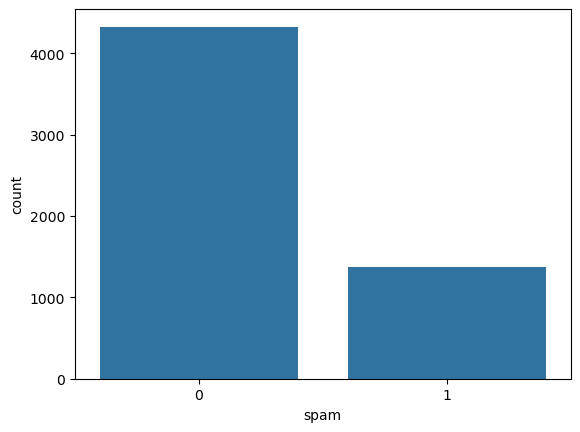

In [23]:
sns.countplot(x = 'spam', data = df )
plt.show()

In [24]:
df['length'] = df['text'].apply(len)

C:\Users\jaimi\AppData\Local\Temp\ipykernel_12584\2995275693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['length'] = df['text'].apply(len)


In [25]:
df.head()

,text,spam,length
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [31]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

C:\Users\jaimi\AppData\Local\Temp\ipykernel_12584\2512967891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['text'].apply(lambda x: len(x.split()))


In [45]:
df.head()

,text,spam,length,word_count
0,Subject: naturally irresistible your corporate...,1,1484,324
1,Subject: the stock trading gunslinger fanny i...,1,598,89
2,Subject: unbelievable new homes made easy im ...,1,448,87
3,Subject: 4 color printing special request add...,1,500,98
4,"Subject: do not have money , get software cds ...",1,235,52


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [47]:
tfidf = TfidfVectorizer()

In [48]:
x = tfidf.fit_transform(df['text'])

In [34]:
y = df['spam']

In [49]:
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 704610 stored elements and shape (5695, 37303)>

In [36]:
y

0       1
1       1
2       1
3       1
4       1
       ..
5723    0
5724    0
5725    0
5726    0
5727    0
Name: spam, Length: 5695, dtype: int64

In [60]:
x_train, x_test, y_train, y_test = train_test_split (x,y, test_size = 0.2 , random_state = 42)

In [61]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 566845 stored elements and shape (4556, 37303)>

In [62]:
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 137765 stored elements and shape (1139, 37303)>

In [63]:
y_test

1436    0
748     1
4126    0
1448    0
3905    0
       ..
2765    0
219     1
1831    0
1115    1
582     1
Name: spam, Length: 1139, dtype: int64

In [64]:
y_test

1436    0
748     1
4126    0
1448    0
3905    0
       ..
2765    0
219     1
1831    0
1115    1
582     1
Name: spam, Length: 1139, dtype: int64

In [65]:
model = LogisticRegression()

In [66]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
y_pred = model.predict(x_test)

In [69]:
y_pred

array([0, 1, 0, ..., 0, 1, 1], shape=(1139,))

In [70]:
model.score(x_train, y_train)

0.9967076382791923

In [71]:
model.score(x_test, y_test)

0.9771729587357331

In [72]:
acc = accuracy_score(y_test, y_pred)

In [73]:
acc

0.9771729587357331

In [74]:
acc*100

97.7172958735733

In [76]:
from sklearn.metrics import confusion_matrix

In [77]:
cm = confusion_matrix(y_test ,y_pred)

In [78]:
cm

array([[842,   1],
       [ 25, 271]])

In [81]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [82]:
precision = precision_score(y_test, y_pred)

In [83]:
precision

0.9963235294117647

In [87]:
recall = recall_score(y_test, y_pred)
recall

0.9155405405405406

In [91]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f1)

0.954225352112676
